   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      

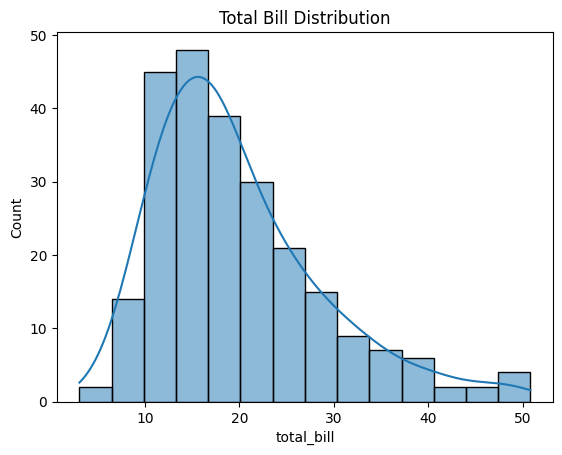

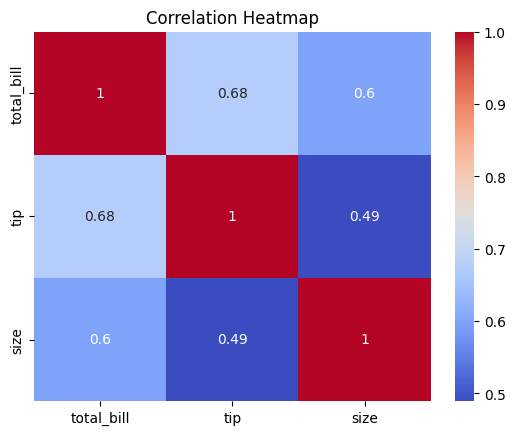

In [5]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

print(df.head())
print(df.info())
print(df.describe())

#visualization
sns.histplot((df['total_bill']), kde=True)
plt.title('Total Bill Distribution')
plt.show()

#correlation matrix
df2 = df.drop(columns=['sex', 'smoker', 'day', 'time'])
corr = df2.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [7]:
from scipy.stats import ttest_ind
 
male_tips = df[df['sex'] == 'Male']['tip']
female_tips = df[df['sex'] == 'Female']['tip']

t_stat, p_value = ttest_ind(male_tips, female_tips)
print(f"t-statistic: {t_stat}, p-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference in tips between males and females.")
else:
    print("Fail to reject the null hypothesis: No significant difference in tips between males and females.")

t-statistic: 1.387859705421269, p-value: 0.16645623503456755
Fail to reject the null hypothesis: No significant difference in tips between males and females.


Coefficient: 0.10502451738435337, Intercept: 0.9202696135546731, R^2: 0.45661658635167657


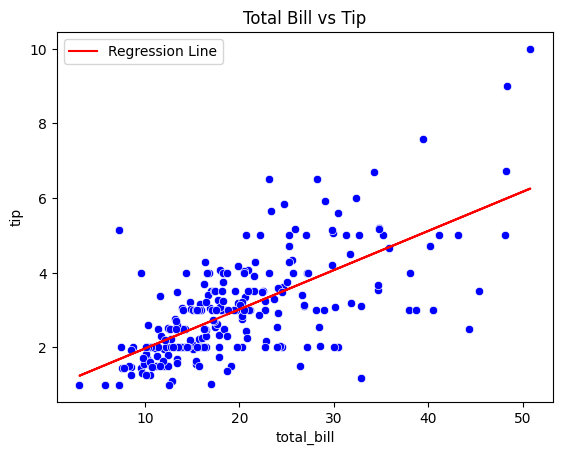

In [8]:
from sklearn.linear_model import LinearRegression
import numpy as np 

x = df['total_bill'].values.reshape(-1, 1)
y = df['tip'].values

model = LinearRegression()
model.fit(x, y)

print (f"Coefficient: {model.coef_[0]}, Intercept: {model.intercept_}, R^2: {model.score(x, y)}")

#plot regression line
sns.scatterplot(x='total_bill', y='tip', data=df, color='blue')
plt.plot(df['total_bill'], model.predict(x), color='red', label='Regression Line')
plt.title('Total Bill vs Tip')
plt.legend()
plt.show()

In [ ]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['smoker'], df['time'])

chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square statistic: {chi2}, p-value: {p}")
alpha = 0.05
if p < alpha:
    print("Reject the null hypothesis: There is an association between smoking status and time of day.")
else:
    print("Fail to reject the null hypothesis: No association between smoking status and time of day.")